<a href="https://colab.research.google.com/github/muwanguziemmanuel2404/Product-Sales/blob/main/A00021157.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Installation and Importing Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

# Set global style
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.format': 'png'
})

PALETTE = {
    'blue':   '#2C6FAC',
    'orange': '#E87722',
    'green':  '#3DAA6B',
    'red':    '#C0392B',
    'purple': '#7B4F9E',
    'grey':   '#95A5A6',
}

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
# Loading the Dataset

#df = pd.read_csv('Prodcut_Sales__1_.csv', encoding='utf-8-sig')
df = pd.read_csv('/content/drive/MyDrive/Data Visualization/Product_Sales.csv', encoding='utf-8-sig')

print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Dataset loaded: 9,994 rows × 19 columns

Column names:
['Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

First 5 rows:


,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,CA-2016-152156,08/11/2016,11/11/2016,Second Class,CG-12520,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,CA-2016-152156,08/11/2016,11/11/2016,Second Class,CG-12520,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,CA-2016-138688,12/06/2016,16/06/2016,Second Class,DV-13045,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,US-2015-108966,11/10/2015,18/10/2015,Standard Class,SO-20335,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,US-2015-108966,11/10/2015,18/10/2015,Standard Class,SO-20335,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
# Data Preparation and Cleaning

# Inspect data types and missing values
print("=== Data Types ===")
print(df.dtypes)

print("\n=== Missing Values ===")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else "No missing values found.")

# Parse dates
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date']  = pd.to_datetime(df['Ship Date'],  dayfirst=True)
df['Order Year']  = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Month Name'] = df['Order Date'].dt.strftime('%b')
df['Lead Time (Days)'] = (df['Ship Date'] - df['Order Date']).dt.days

print("\nDate columns parsed. Lead time stats:")
print(df['Lead Time (Days)'].describe())

# Check for duplicates
dupes = df.duplicated().sum()
print(f"\nDuplicate rows: {dupes}")

# Outlier detection using IQR for Sales and Profit
def flag_outliers(series, label):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = series[(series < lower) | (series > upper)]
    print(f"{label}: Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f} | "
          f"Bounds=[{lower:.2f}, {upper:.2f}] | Outliers={len(outliers)} "
          f"({100*len(outliers)/len(series):.1f}%)")
    return lower, upper

print("\n=== Outlier Detection (IQR method) ===")
sales_lo, sales_hi = flag_outliers(df['Sales'], 'Sales')
profit_lo, profit_hi = flag_outliers(df['Profit'], 'Profit')
flag_outliers(df['Quantity'], 'Quantity')

# Flag but retain outliers — they represent real, high-value transactions
df['Sales_Outlier']  = (df['Sales']  < sales_lo)  | (df['Sales']  > sales_hi)
df['Profit_Outlier'] = (df['Profit'] < profit_lo) | (df['Profit'] > profit_hi)

# Derived features
df['Profit Margin (%)'] = (df['Profit'] / df['Sales'].replace(0, np.nan)) * 100
df['Revenue per Unit']  = df['Sales'] / df['Quantity']

print("\n=== Summary Statistics ===")
print(df[['Sales', 'Profit', 'Quantity', 'Discount', 'Profit Margin (%)']].describe().round(2))

=== Data Types ===
Order ID         object
Order Date       object
Ship Date        object
Ship Mode        object
Customer ID      object
Segment          object
Country          object
City             object
State            object
Postal Code       int64
Region           object
Product ID       object
Category         object
Sub-Category     object
Product Name     object
Sales           float64
Quantity          int64
Discount        float64
Profit          float64
dtype: object

=== Missing Values ===
No missing values found.

Date columns parsed. Lead time stats:
count    9994.000000
mean        3.958175
std         1.747567
min         0.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         7.000000
Name: Lead Time (Days), dtype: float64

Duplicate rows: 1

=== Outlier Detection (IQR method) ===
Sales: Q1=17.28, Q3=209.94, IQR=192.66 | Bounds=[-271.71, 498.93] | Outliers=1167 (11.7%)
Profit: Q1=1.73, Q3=29.36, IQR=27.64 | Bounds=[-39.72, 70.82] | Out

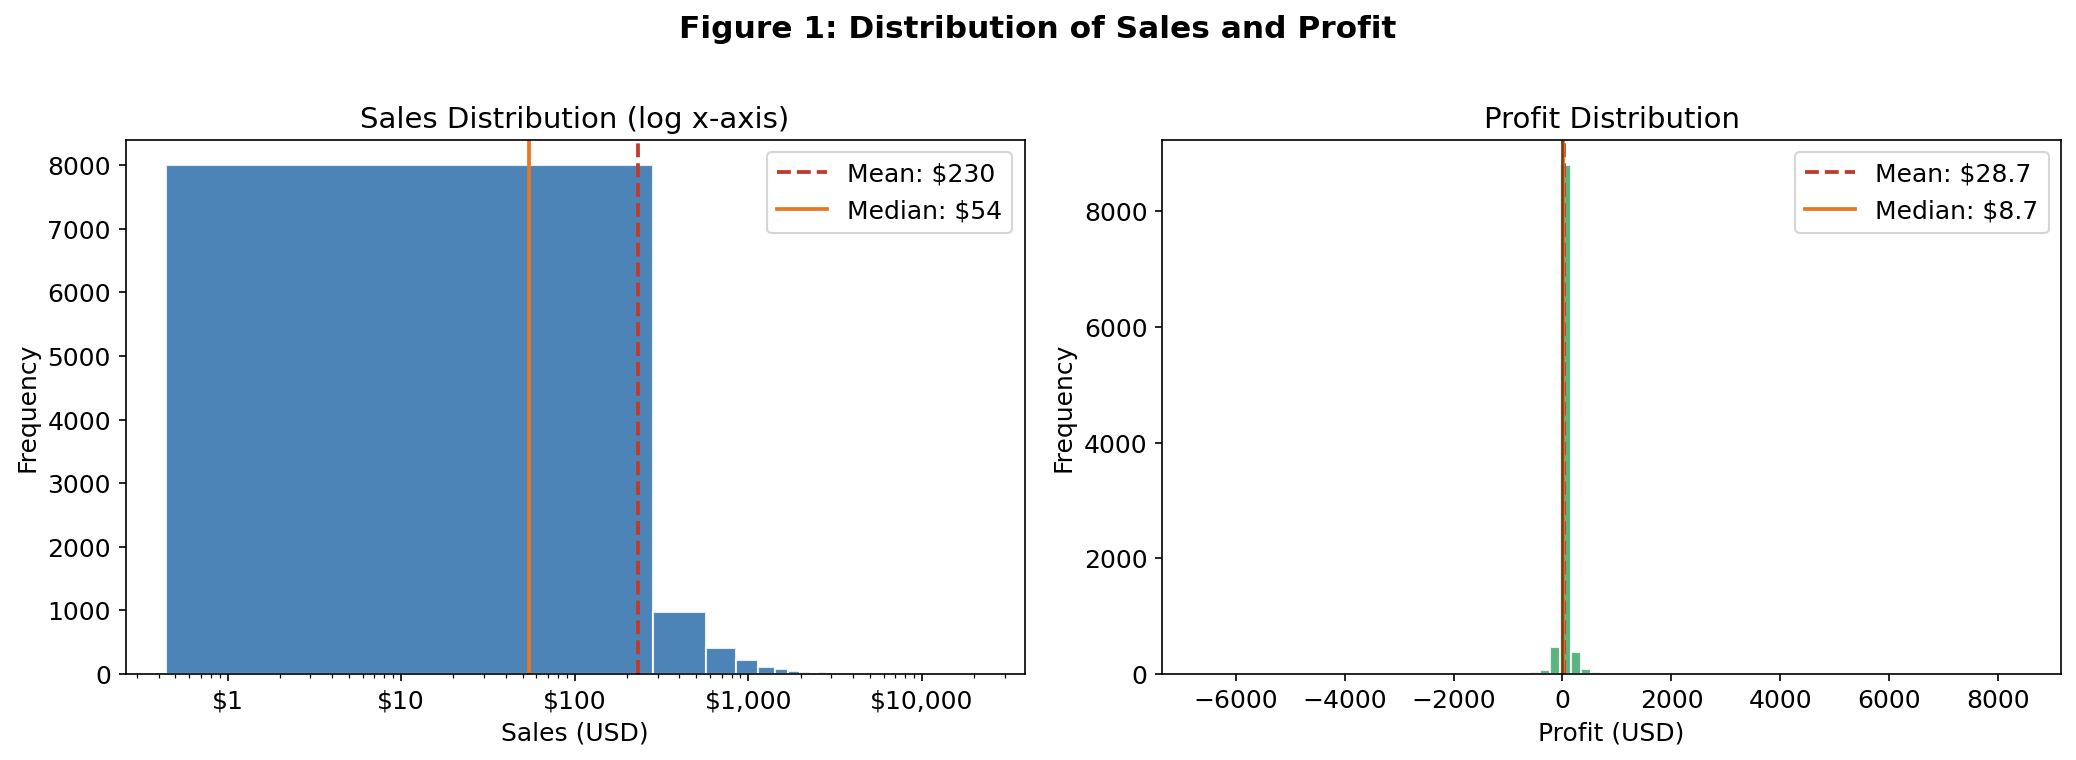

Figure 1 saved.


In [ ]:
# EDA — Figure 1: Distribution of Sales and Profit

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 1: Distribution of Sales and Profit', fontsize=15, fontweight='bold', y=1.01)

# Sales distribution (log scale for skewed data)
axes[0].hist(df['Sales'], bins=80, color=PALETTE['blue'], edgecolor='white', alpha=0.85)
axes[0].axvline(df['Sales'].mean(),   color=PALETTE['red'],    linestyle='--', linewidth=1.8, label=f"Mean: ${df['Sales'].mean():,.0f}")
axes[0].axvline(df['Sales'].median(), color=PALETTE['orange'], linestyle='-',  linewidth=1.8, label=f"Median: ${df['Sales'].median():,.0f}")
axes[0].set_xlabel('Sales (USD)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Sales Distribution (log x-axis)')
axes[0].set_xscale('log')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Profit distribution
axes[1].hist(df['Profit'], bins=80, color=PALETTE['green'], edgecolor='white', alpha=0.85)
axes[1].axvline(df['Profit'].mean(),   color=PALETTE['red'],    linestyle='--', linewidth=1.8, label=f"Mean: ${df['Profit'].mean():,.1f}")
axes[1].axvline(df['Profit'].median(), color=PALETTE['orange'], linestyle='-',  linewidth=1.8, label=f"Median: ${df['Profit'].median():,.1f}")
axes[1].axvline(0, color='black', linewidth=1.2, alpha=0.5)
axes[1].set_xlabel('Profit (USD)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Profit Distribution')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig1_sales_profit_distribution.png')
plt.show()
print("Figure 1 saved.")

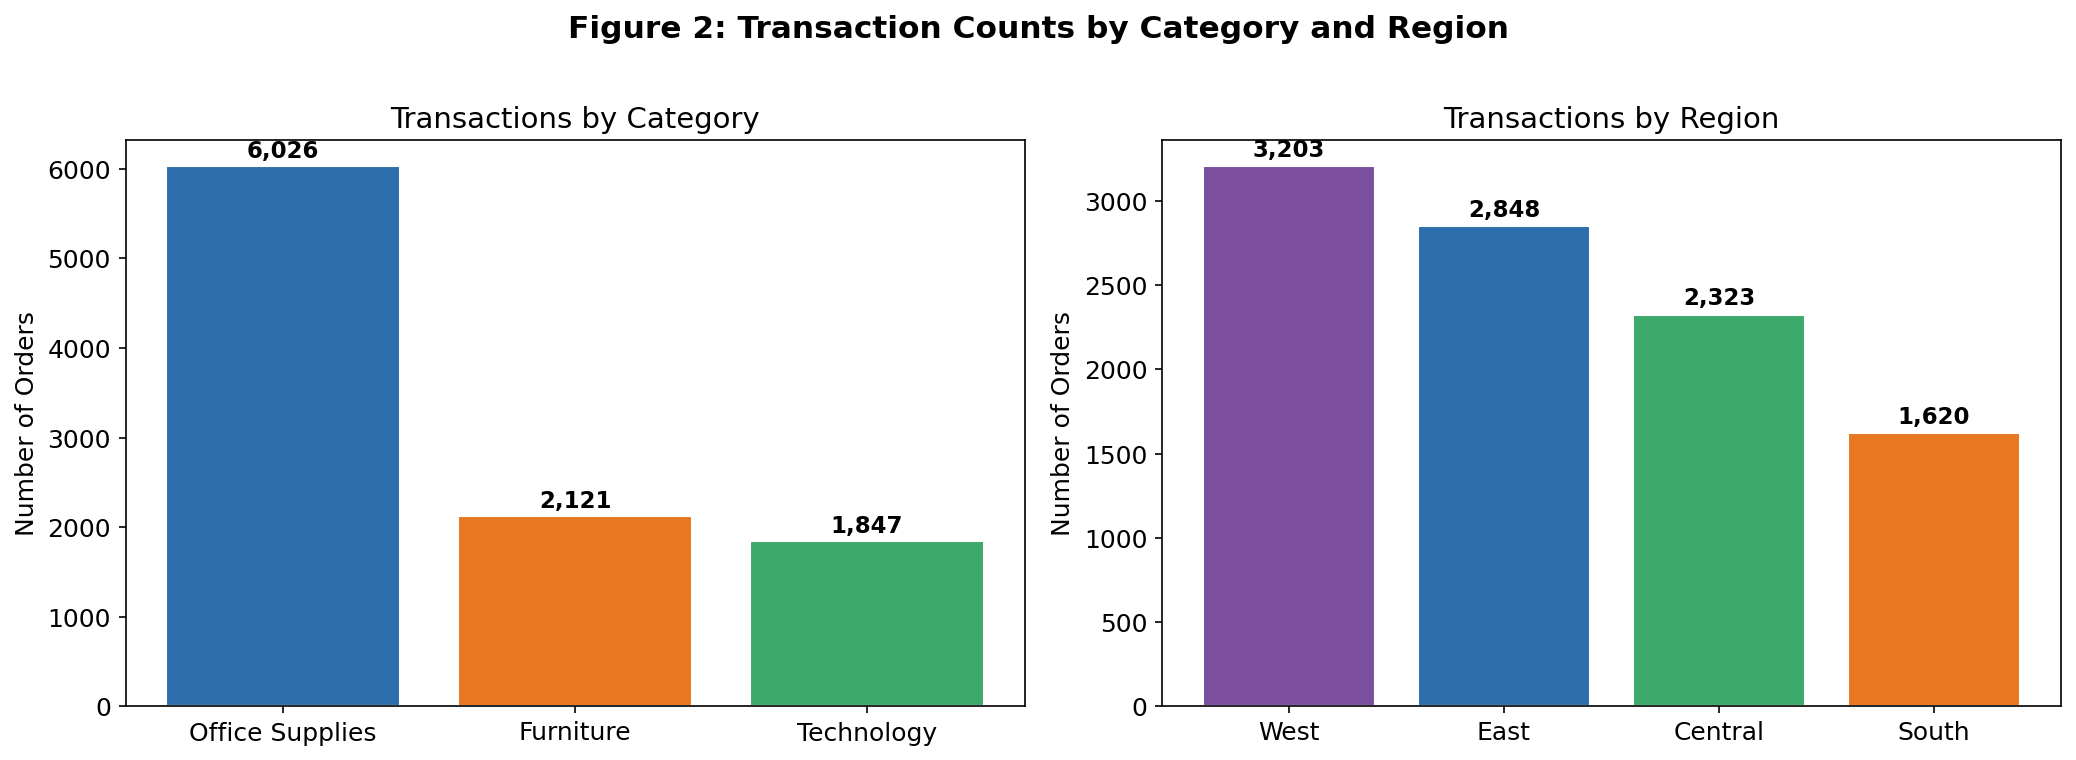

Figure 2 saved.


In [ ]:
# EDA — Figure 2: Category and Region Breakdown

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 2: Transaction Counts by Category and Region', fontsize=15, fontweight='bold', y=1.01)

cat_counts = df['Category'].value_counts()
reg_counts  = df['Region'].value_counts()

colors_cat = [PALETTE['blue'], PALETTE['orange'], PALETTE['green']]
colors_reg  = [PALETTE['purple'], PALETTE['blue'], PALETTE['green'], PALETTE['orange']]

bars1 = axes[0].bar(cat_counts.index, cat_counts.values, color=colors_cat, edgecolor='white')
axes[0].set_title('Transactions by Category')
axes[0].set_ylabel('Number of Orders')
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 40,
                 f'{bar.get_height():,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

bars2 = axes[1].bar(reg_counts.index, reg_counts.values, color=colors_reg, edgecolor='white')
axes[1].set_title('Transactions by Region')
axes[1].set_ylabel('Number of Orders')
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{bar.get_height():,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('fig2_category_region_breakdown.png')
plt.show()
print("Figure 2 saved.")

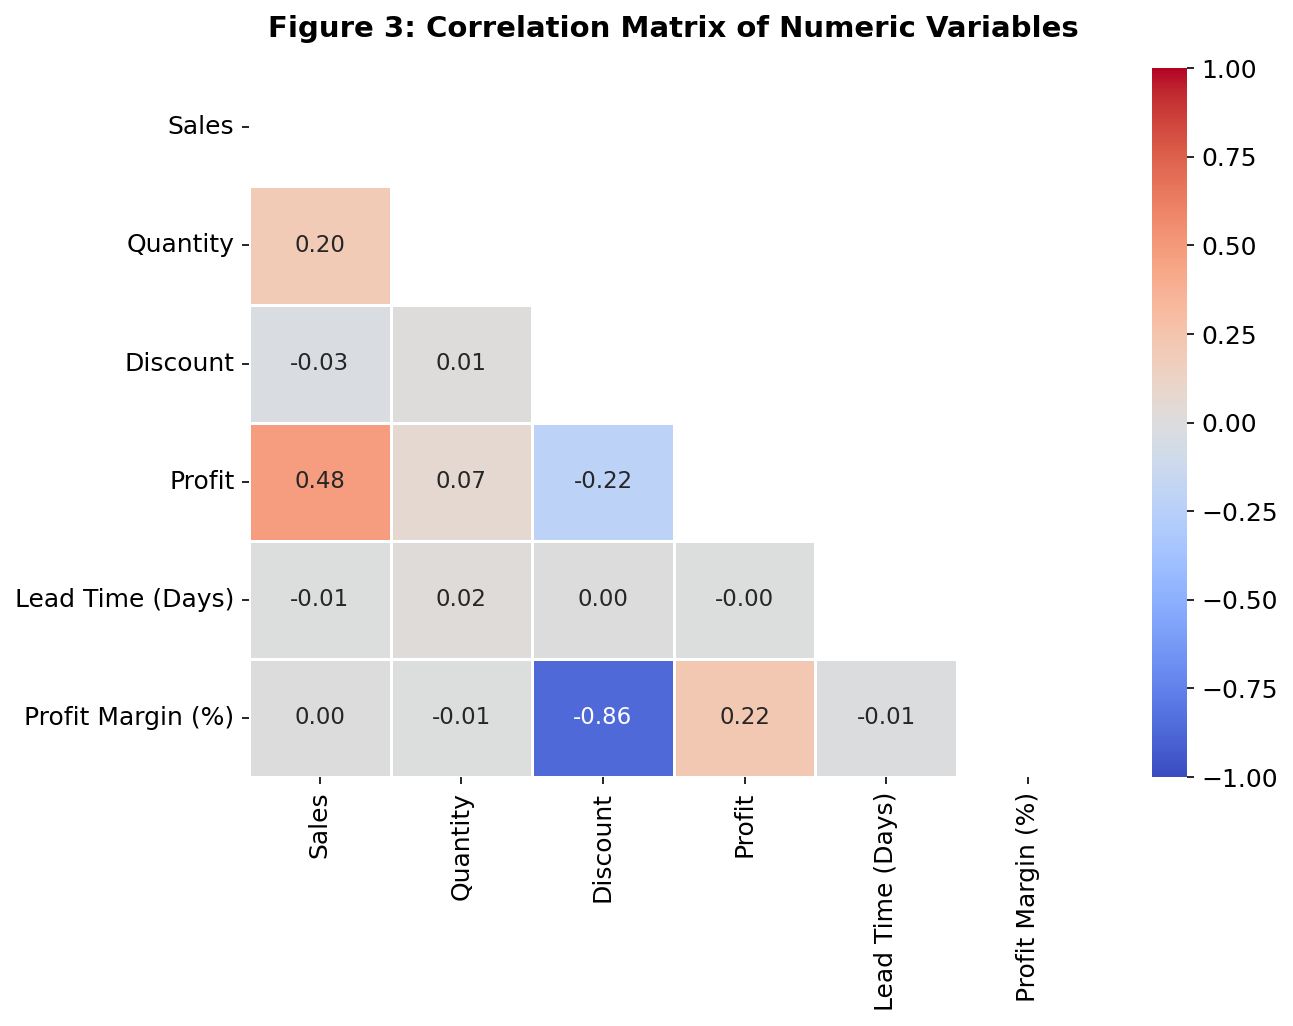

Figure 3 saved.

Notable correlations:
  Sales vs Profit: r = 0.479
  Discount vs Profit Margin (%): r = -0.864


In [ ]:
# EDA — Figure 3: Correlation Heatmap

numeric_cols = ['Sales', 'Quantity', 'Discount', 'Profit', 'Lead Time (Days)', 'Profit Margin (%)']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 11},
            vmin=-1, vmax=1)
ax.set_title('Figure 3: Correlation Matrix of Numeric Variables', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('fig3_correlation_heatmap.png')
plt.show()
print("Figure 3 saved.")

# Print notable correlations
print("\nNotable correlations:")
for i in range(len(numeric_cols)):
    for j in range(i+1, len(numeric_cols)):
        v = corr.iloc[i, j]
        if abs(v) > 0.3:
            print(f"  {numeric_cols[i]} vs {numeric_cols[j]}: r = {v:.3f}")


=== RQ1: Discount vs Profitability by Category ===


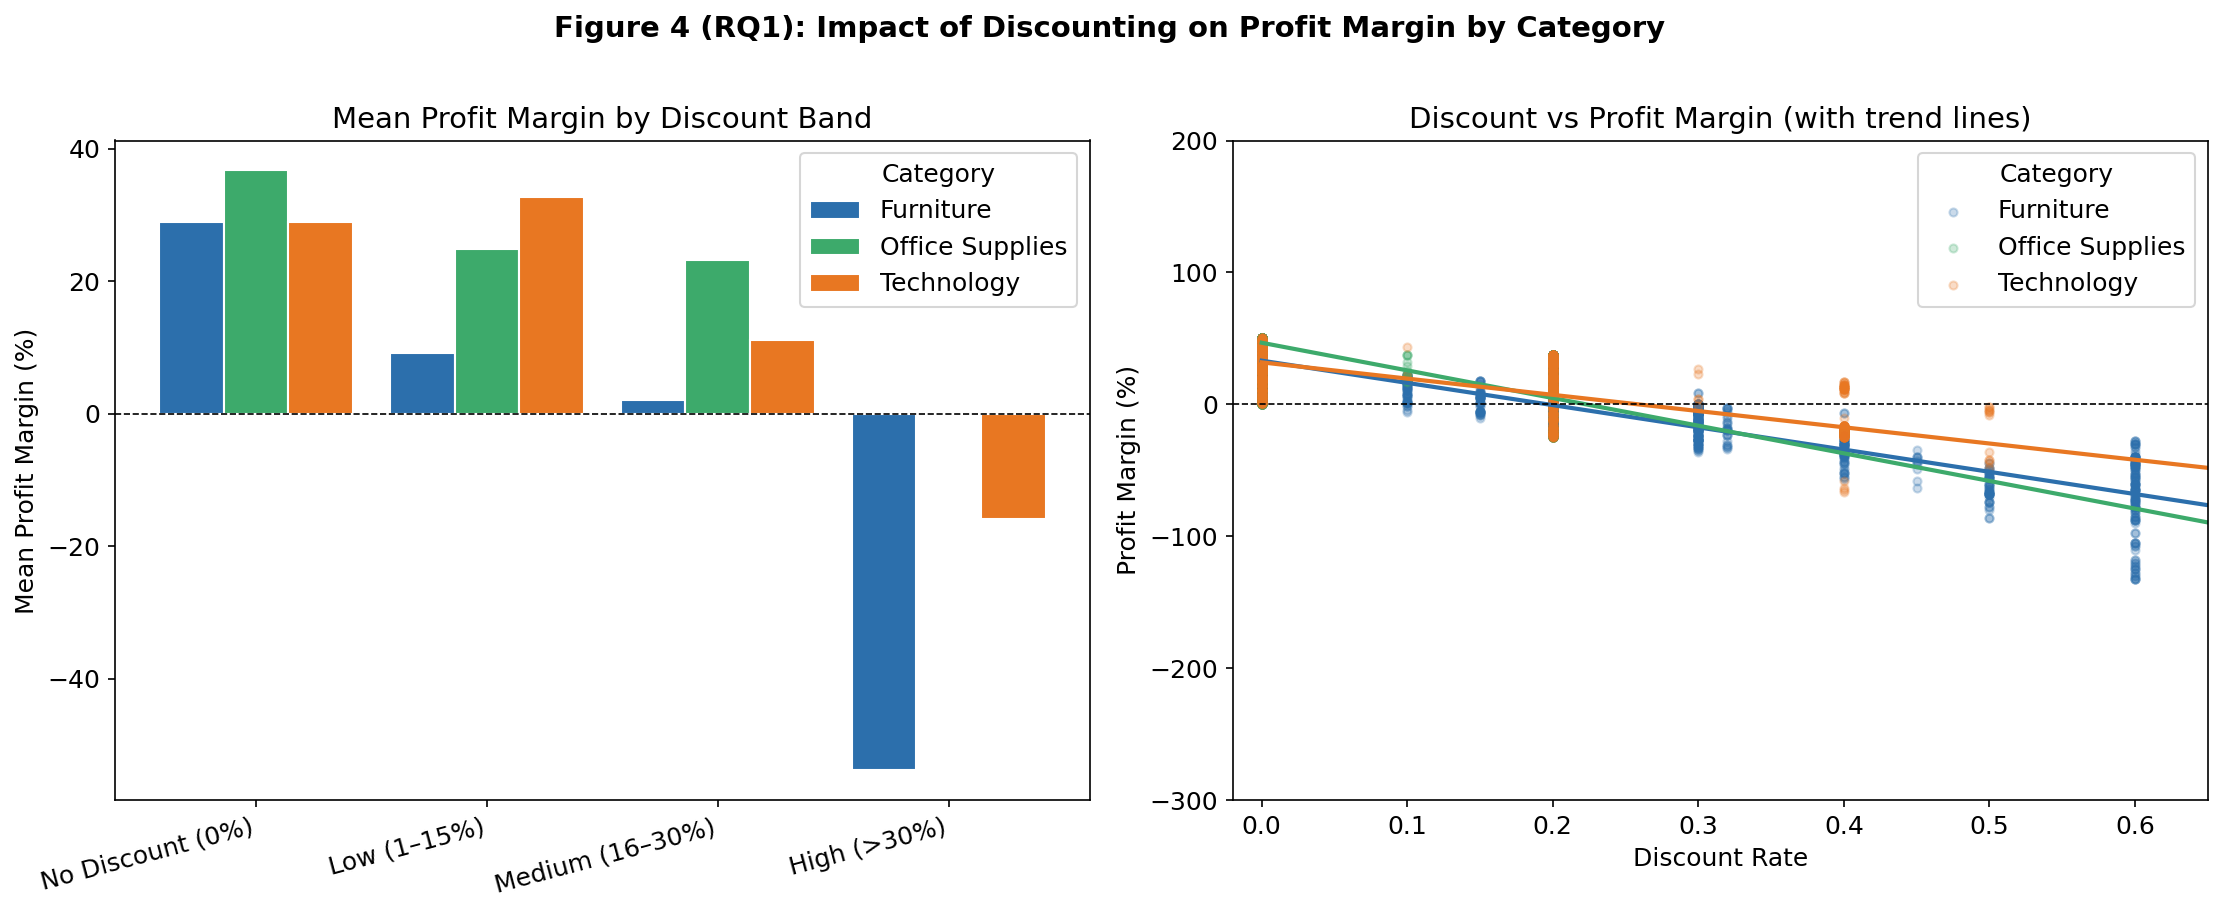

Furniture: r(Discount, ProfitMargin) = -0.888, p = 0.0000
Office Supplies: r(Discount, ProfitMargin) = -0.877, p = 0.0000
Technology: r(Discount, ProfitMargin) = -0.755, p = 0.0000
Figure 4 saved.


In [ ]:
# Research Question 1
# How does discount level affect profitability across product categories?

print("\n=== RQ1: Discount vs Profitability by Category ===")

df['Discount Band'] = pd.cut(df['Discount'],
    bins=[-0.01, 0.0, 0.15, 0.30, 0.60],
    labels=['No Discount (0%)', 'Low (1–15%)', 'Medium (16–30%)', 'High (>30%)'])

rq1_data = df.groupby(['Category', 'Discount Band'], observed=True)['Profit Margin (%)'].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Figure 4 (RQ1): Impact of Discounting on Profit Margin by Category',
             fontsize=14, fontweight='bold', y=1.01)

# Grouped bar chart
cat_palette = {'Furniture': PALETTE['blue'], 'Office Supplies': PALETTE['green'], 'Technology': PALETTE['orange']}
x = np.arange(4)
width = 0.28
bands = ['No Discount (0%)', 'Low (1–15%)', 'Medium (16–30%)', 'High (>30%)']
for i, cat in enumerate(['Furniture', 'Office Supplies', 'Technology']):
    vals = []
    for band in bands:
        sub = rq1_data[(rq1_data['Category']==cat) & (rq1_data['Discount Band']==band)]
        vals.append(sub['Profit Margin (%)'].values[0] if len(sub) else 0)
    bars = axes[0].bar(x + i*width, vals, width, label=cat, color=cat_palette[cat], edgecolor='white')

axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(bands, rotation=15, ha='right')
axes[0].set_ylabel('Mean Profit Margin (%)')
axes[0].set_title('Mean Profit Margin by Discount Band')
axes[0].legend(title='Category')

# Scatter: Discount vs Profit coloured by Category
for cat, col in cat_palette.items():
    sub = df[df['Category'] == cat]
    axes[1].scatter(sub['Discount'], sub['Profit Margin (%)'],
                    alpha=0.25, s=15, color=col, label=cat)
    # Trend line
    m, b, r, p, _ = stats.linregress(sub['Discount'], sub['Profit Margin (%)'])
    x_line = np.linspace(0, sub['Discount'].max(), 100)
    axes[1].plot(x_line, m*x_line + b, color=col, linewidth=2)

axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_xlabel('Discount Rate')
axes[1].set_ylabel('Profit Margin (%)')
axes[1].set_title('Discount vs Profit Margin (with trend lines)')
axes[1].legend(title='Category')
axes[1].set_xlim(-0.02, 0.65)
axes[1].set_ylim(-300, 200)

plt.tight_layout()
plt.savefig('fig4_rq1_discount_profitability.png')
plt.show()

# Print stats
for cat in ['Furniture', 'Office Supplies', 'Technology']:
    sub = df[df['Category'] == cat]
    r, p = stats.pearsonr(sub['Discount'], sub['Profit Margin (%)'])
    print(f"{cat}: r(Discount, ProfitMargin) = {r:.3f}, p = {p:.4f}")
print("Figure 4 saved.")


=== RQ2: Revenue & Profit by Segment and Region ===


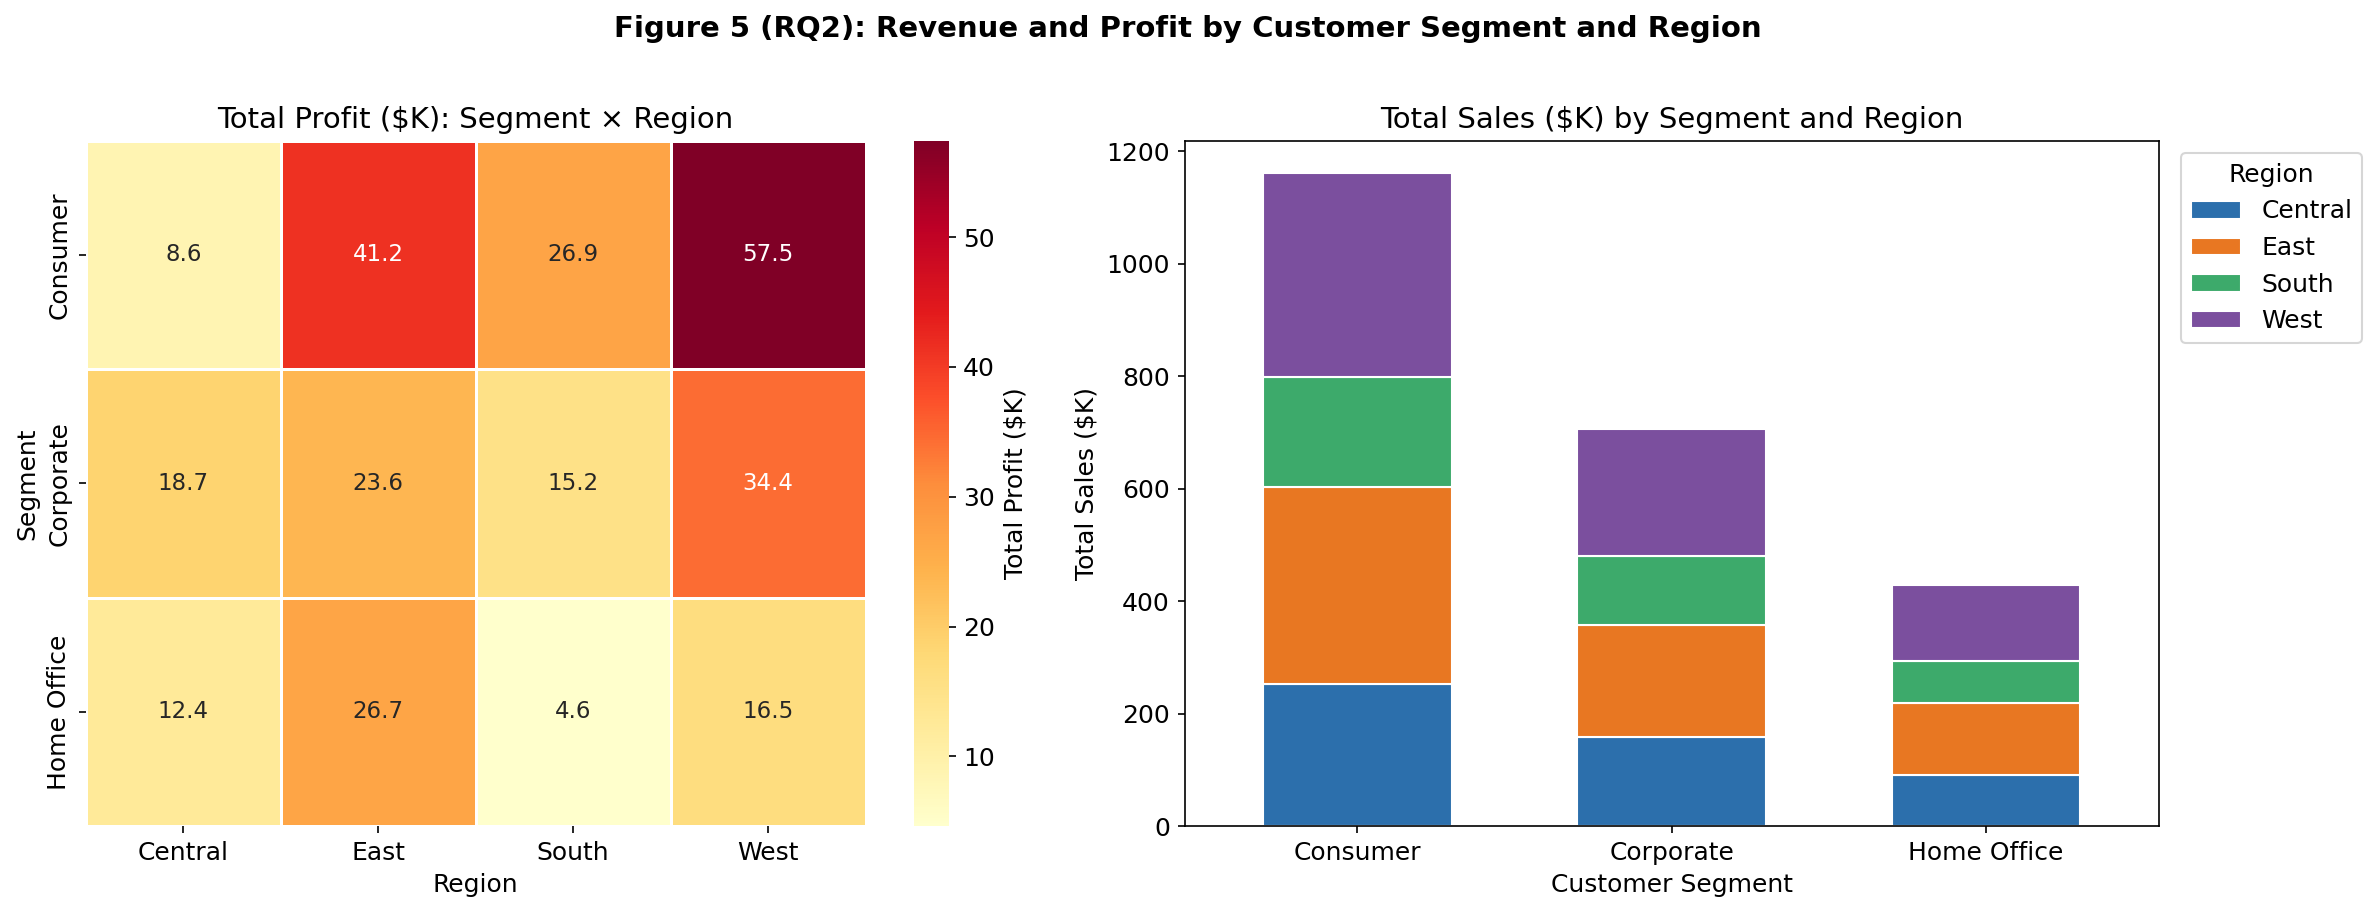


Total profit by segment ($):
Segment
Consumer       134119.21
Corporate       91979.13
Home Office     60298.68

Total sales by region ($K):
Region
Central    501.2
East       678.8
South      391.7
West       725.5
Figure 5 saved.


In [ ]:
# Research Question 2
# Which customer segments and regions drive the highest revenue and profit?

print("\n=== RQ2: Revenue & Profit by Segment and Region ===")

# Pivot: Segment × Region profit
pivot_profit = df.pivot_table(values='Profit', index='Segment',
                               columns='Region', aggfunc='sum') / 1000  # in $K

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Figure 5 (RQ2): Revenue and Profit by Customer Segment and Region',
             fontsize=14, fontweight='bold', y=1.01)

# Heatmap: total profit by segment × region
sns.heatmap(pivot_profit, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=axes[0], annot_kws={'size': 11},
            cbar_kws={'label': 'Total Profit ($K)'})
axes[0].set_title('Total Profit ($K): Segment × Region')
axes[0].set_xlabel('Region')
axes[0].set_ylabel('Segment')

# Stacked bar: sales by segment and region
seg_reg = df.groupby(['Segment', 'Region'])['Sales'].sum().unstack() / 1000
region_colors = [PALETTE['blue'], PALETTE['orange'], PALETTE['green'], PALETTE['purple']]
seg_reg.plot(kind='bar', stacked=True, ax=axes[1], color=region_colors,
             edgecolor='white', width=0.6)
axes[1].set_title('Total Sales ($K) by Segment and Region')
axes[1].set_xlabel('Customer Segment')
axes[1].set_ylabel('Total Sales ($K)')
axes[1].set_xticklabels(seg_reg.index, rotation=0)
axes[1].legend(title='Region', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.savefig('fig5_rq2_segment_region.png')
plt.show()

# Statistics
print("\nTotal profit by segment ($):")
print(df.groupby('Segment')['Profit'].sum().round(2).to_string())
print("\nTotal sales by region ($K):")
print((df.groupby('Region')['Sales'].sum()/1000).round(1).to_string())
print("Figure 5 saved.")


=== RQ3: Temporal Trends in Sales and Profit ===


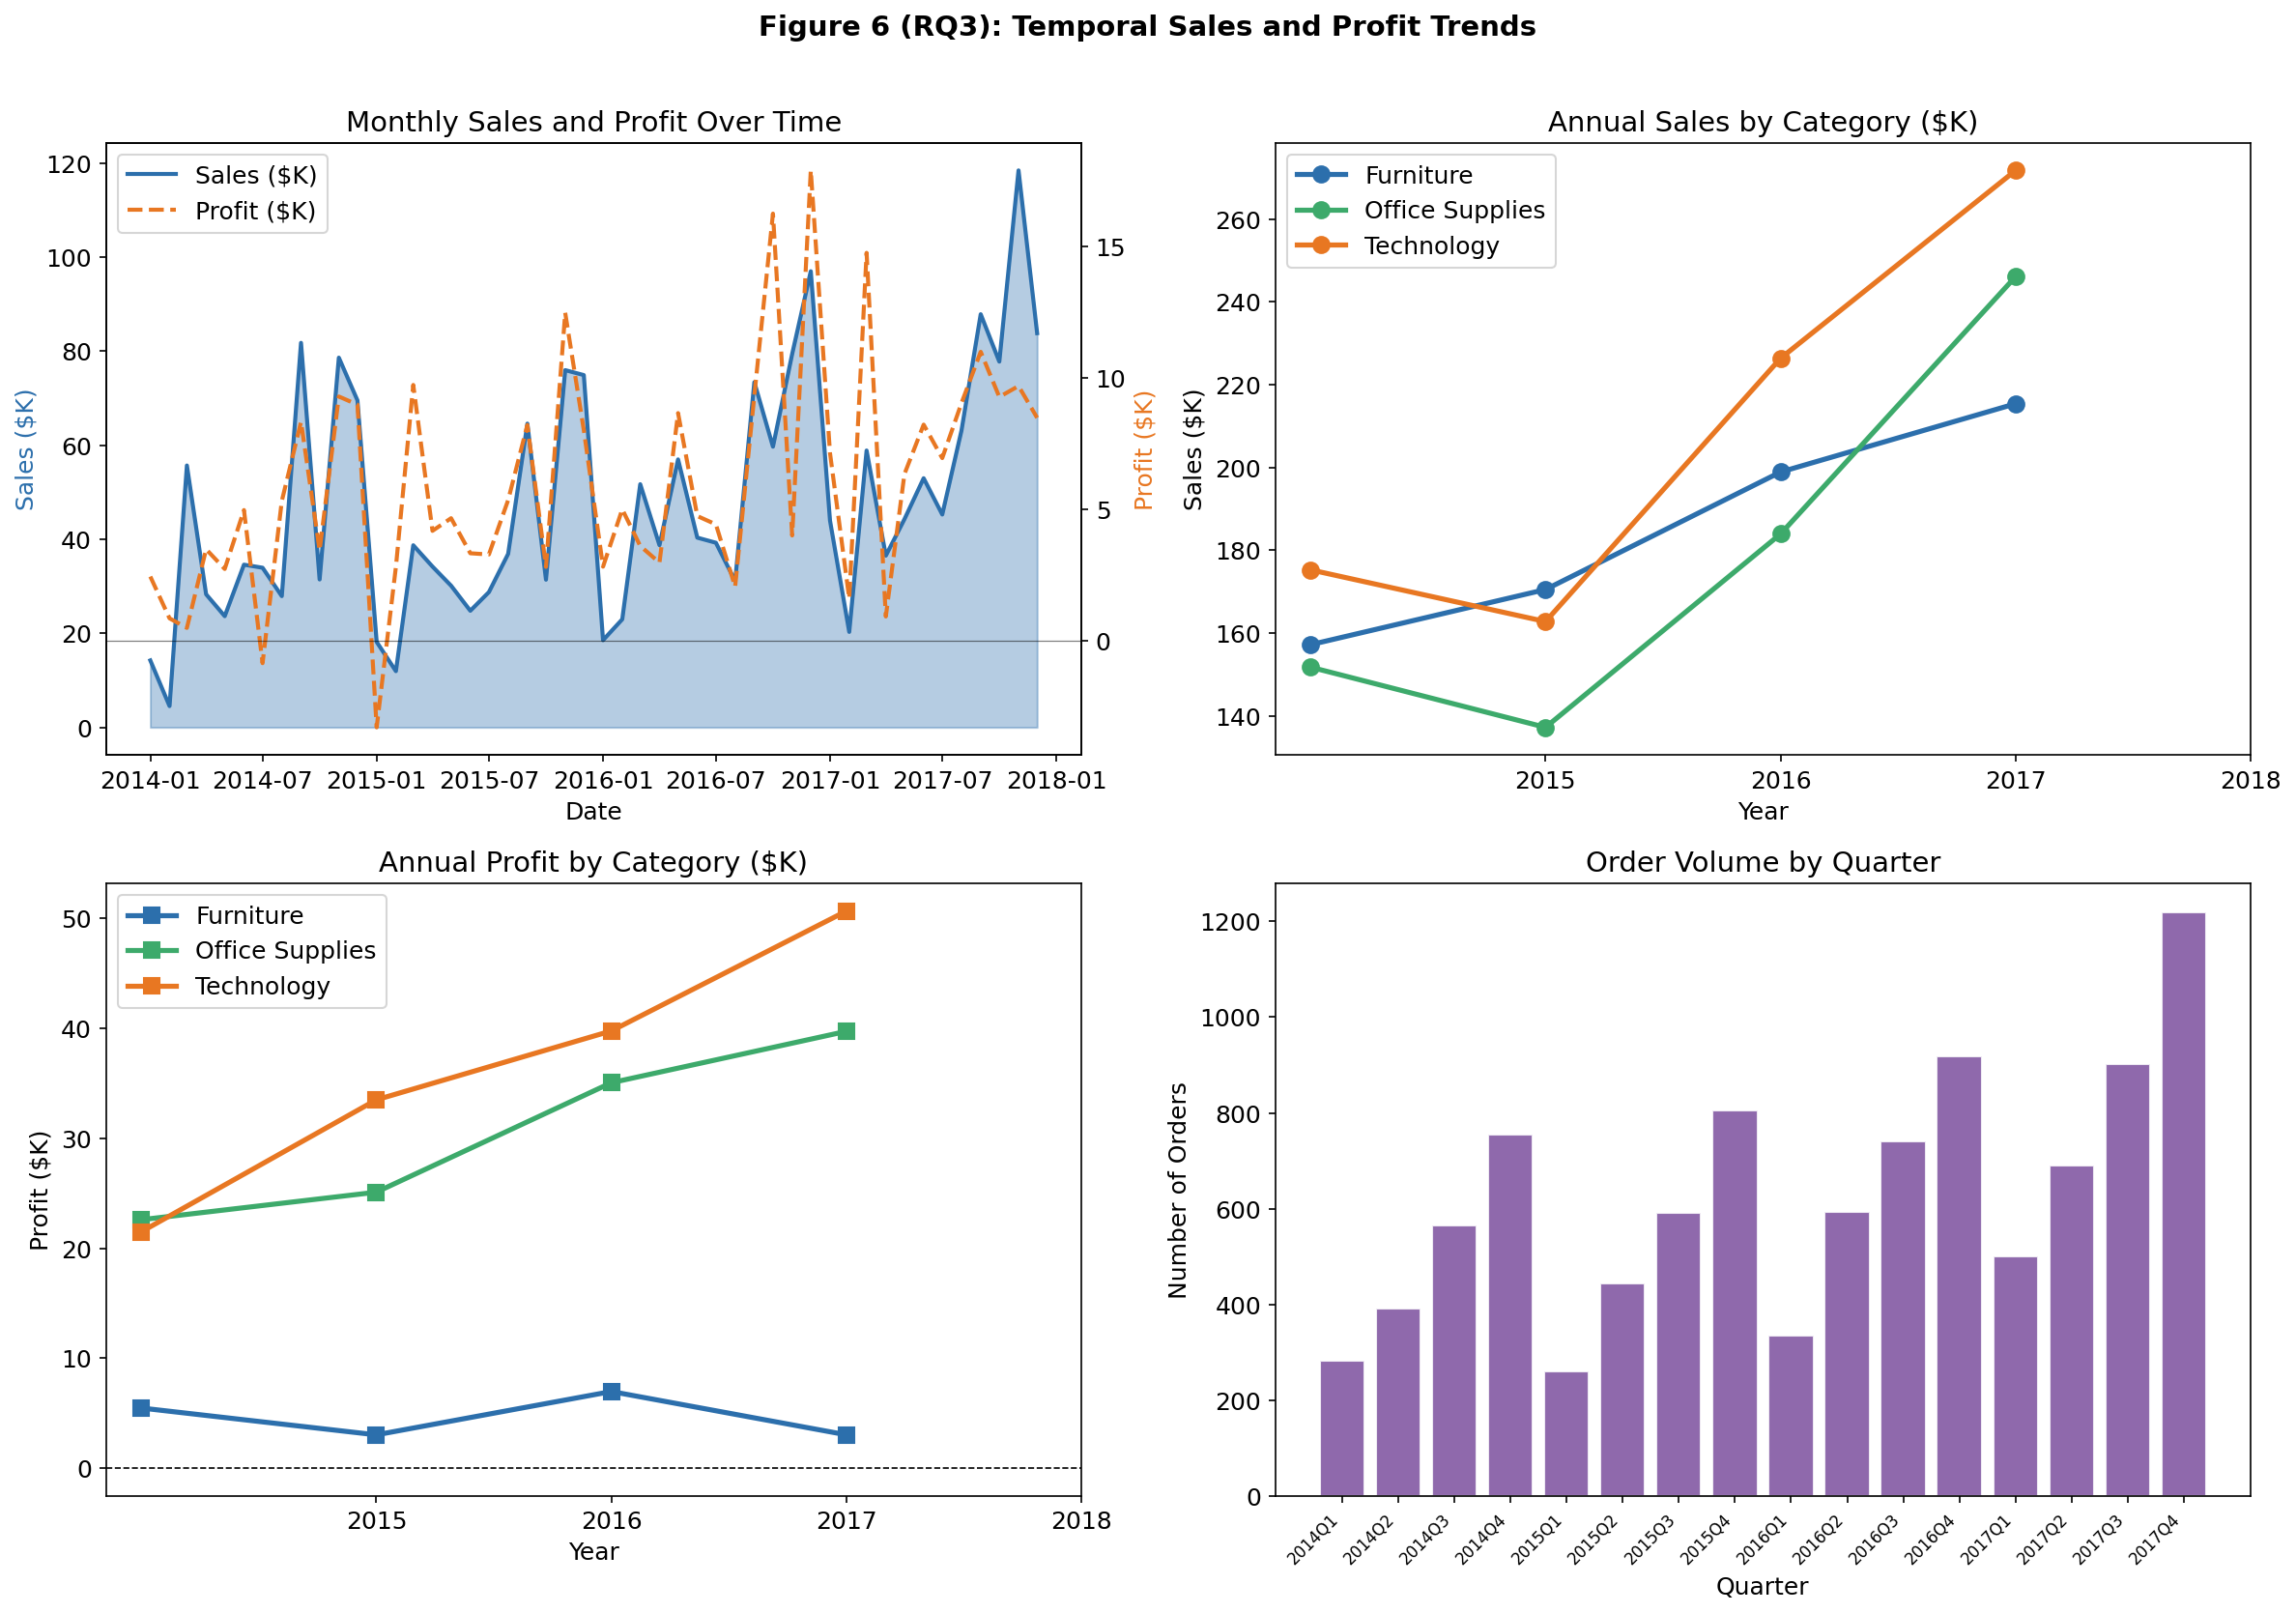

Figure 6 saved.


In [ ]:
# Research Question 3
# How have sales and profit trended over time across product categories?


print("\n=== RQ3: Temporal Trends in Sales and Profit ===")

monthly = df.groupby(['Order Year', 'Order Month']).agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Orders=('Order ID', 'count')
).reset_index()
monthly['Period'] = pd.to_datetime(monthly[['Order Year', 'Order Month']].rename(
    columns={'Order Year':'year', 'Order Month':'month'}).assign(day=1))
monthly = monthly.sort_values('Period')

# Category time series
cat_year = df.groupby(['Category', 'Order Year']).agg(
    Sales=('Sales','sum'), Profit=('Profit','sum')).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Figure 6 (RQ3): Temporal Sales and Profit Trends', fontsize=14, fontweight='bold', y=1.01)

# Top-left: monthly sales and profit
ax1 = axes[0, 0]
ax2 = ax1.twinx()
ax1.fill_between(monthly['Period'], monthly['Sales']/1000, alpha=0.35, color=PALETTE['blue'])
ax1.plot(monthly['Period'], monthly['Sales']/1000, color=PALETTE['blue'], linewidth=2, label='Sales ($K)')
ax2.plot(monthly['Period'], monthly['Profit']/1000, color=PALETTE['orange'], linewidth=2, linestyle='--', label='Profit ($K)')
ax2.axhline(0, color='black', linewidth=0.6, alpha=0.5)
ax1.set_xlabel('Date'); ax1.set_ylabel('Sales ($K)', color=PALETTE['blue'])
ax2.set_ylabel('Profit ($K)', color=PALETTE['orange'])
ax1.set_title('Monthly Sales and Profit Over Time')
lines1, labs1 = ax1.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labs1+labs2, loc='upper left')

# Top-right: Category sales by year
for cat, col in zip(['Furniture', 'Office Supplies', 'Technology'],
                    [PALETTE['blue'], PALETTE['green'], PALETTE['orange']]):
    sub = cat_year[cat_year['Category']==cat]
    axes[0,1].plot(sub['Order Year'], sub['Sales']/1000, marker='o', markersize=8,
                   linewidth=2.5, label=cat, color=col)
axes[0,1].set_title('Annual Sales by Category ($K)')
axes[0,1].set_xlabel('Year'); axes[0,1].set_ylabel('Sales ($K)')
axes[0,1].legend(); axes[0,1].set_xticks([2015,2016,2017,2018])

# Bottom-left: Category profit by year
for cat, col in zip(['Furniture', 'Office Supplies', 'Technology'],
                    [PALETTE['blue'], PALETTE['green'], PALETTE['orange']]):
    sub = cat_year[cat_year['Category']==cat]
    axes[1,0].plot(sub['Order Year'], sub['Profit']/1000, marker='s', markersize=8,
                   linewidth=2.5, label=cat, color=col)
axes[1,0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1,0].set_title('Annual Profit by Category ($K)')
axes[1,0].set_xlabel('Year'); axes[1,0].set_ylabel('Profit ($K)')
axes[1,0].legend(); axes[1,0].set_xticks([2015,2016,2017,2018])

# Bottom-right: Order volume per quarter
df['Quarter'] = df['Order Date'].dt.to_period('Q').astype(str)
qtr = df.groupby('Quarter')['Order ID'].count().reset_index()
qtr.columns = ['Quarter', 'Orders']
axes[1,1].bar(range(len(qtr)), qtr['Orders'], color=PALETTE['purple'], edgecolor='white', alpha=0.85)
axes[1,1].set_xticks(range(len(qtr)))
axes[1,1].set_xticklabels(qtr['Quarter'], rotation=45, ha='right', fontsize=8)
axes[1,1].set_title('Order Volume by Quarter')
axes[1,1].set_xlabel('Quarter'); axes[1,1].set_ylabel('Number of Orders')

plt.tight_layout()
plt.savefig('fig6_rq3_temporal_trends.png')
plt.show()
print("Figure 6 saved.")


 Supporting Figure: Sub-Category Profit Analysis 


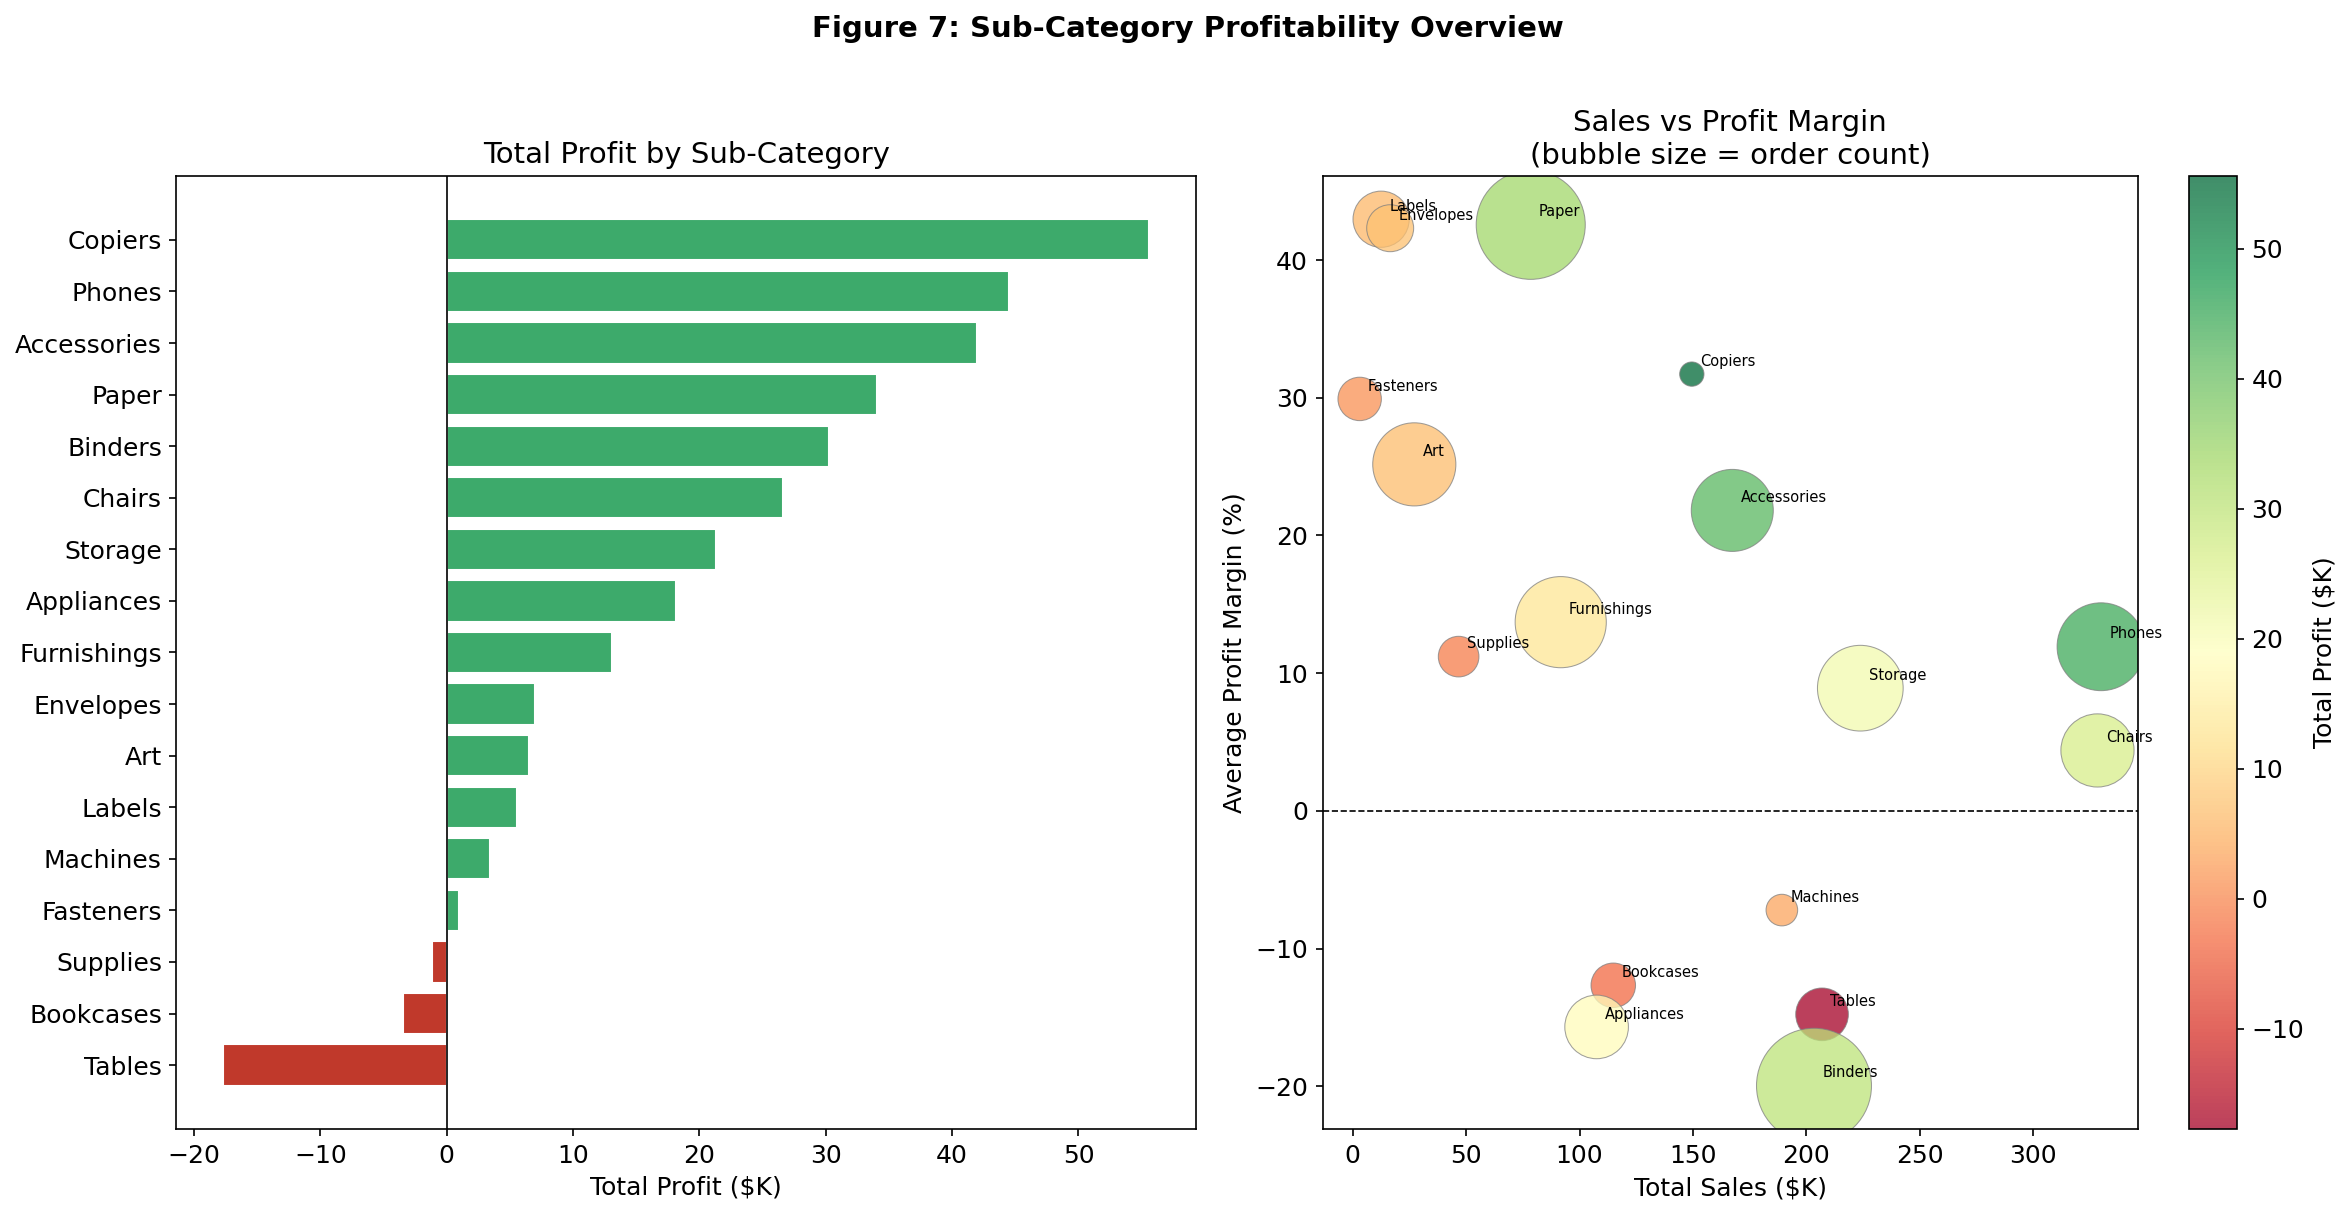

Figure 7 saved.


In [ ]:
# Supporting Figure — Sub-Category Profitability

print("\n Supporting Figure: Sub-Category Profit Analysis ")

subcat = df.groupby('Sub-Category').agg(
    Total_Profit=('Profit', 'sum'),
    Total_Sales=('Sales', 'sum'),
    Avg_Margin=('Profit Margin (%)', 'mean'),
    Orders=('Order ID', 'count')
).reset_index().sort_values('Total_Profit')

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('Figure 7: Sub-Category Profitability Overview', fontsize=14, fontweight='bold', y=1.01)

colors_bar = [PALETTE['red'] if v < 0 else PALETTE['green'] for v in subcat['Total_Profit']]
bars = axes[0].barh(subcat['Sub-Category'], subcat['Total_Profit']/1000,
                    color=colors_bar, edgecolor='white')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Total Profit ($K)')
axes[0].set_title('Total Profit by Sub-Category')

sc = axes[1].scatter(subcat['Total_Sales']/1000, subcat['Avg_Margin'],
                     s=subcat['Orders']*2, alpha=0.75,
                     c=subcat['Total_Profit']/1000, cmap='RdYlGn',
                     edgecolors='grey', linewidths=0.5)
for _, row in subcat.iterrows():
    axes[1].annotate(row['Sub-Category'],
                     (row['Total_Sales']/1000, row['Avg_Margin']),
                     textcoords='offset points', xytext=(4, 4), fontsize=7)
cbar = plt.colorbar(sc, ax=axes[1])
cbar.set_label('Total Profit ($K)')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_xlabel('Total Sales ($K)')
axes[1].set_ylabel('Average Profit Margin (%)')
axes[1].set_title('Sales vs Profit Margin\n(bubble size = order count)')

plt.tight_layout()
plt.savefig('fig7_subcategory_profitability.png')
plt.show()
print("Figure 7 saved.")

In [ ]:
# Summary Statistics Table

print("\n Final Summary Statistics ")
summary = df.groupby('Category').agg(
    Transactions=('Order ID', 'count'),
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Avg_Discount=('Discount', 'mean'),
    Avg_Profit_Margin=('Profit Margin (%)', 'mean'),
    Loss_Orders=('Profit', lambda x: (x < 0).sum())
).round(2)
summary['Profit Margin (%)'] = summary['Avg_Profit_Margin'].round(1)
summary['Loss Rate (%)'] = (summary['Loss_Orders'] / summary['Transactions'] * 100).round(1)
print(summary[['Transactions','Total_Sales','Total_Profit','Avg_Discount','Profit Margin (%)','Loss Rate (%)']].to_string())




 Final Summary Statistics 
                 Transactions  Total_Sales  Total_Profit  Avg_Discount  Profit Margin (%)  Loss Rate (%)
Category                                                                                                
Furniture                2121    741999.80      18451.27          0.17                3.9           33.7
Office Supplies          6026    719047.03     122490.80          0.16               13.8           14.7
Technology               1847    836154.03     145454.95          0.13               15.6           14.7
